# FOMC Speaker Hawk/Dove — Configurable Backtest, 2019 – 2026

`usd_fomc_manual_labels_backtest.ipynb` reports one backtest. Every choice inside it was fixed:
the 3rd quarterly contract, a T−45 / T+180 window, every speaker on the roster, equal weight, no
cost. Each was a decision, and none was obviously right.

Here those choices are **a dict**. One `CONFIG` fully describes one backtest — instrument, window,
which speakers, sizing, cost — so changing a knob is an edit to data, not to code, and two configs
can be compared without either of them being privileged.

```python
CONFIG = {
    "instrument": {"kind": "outright", "rank": 3},      # or {"structure": "FLY_2_3_4"}
    "timing":     {"entry_offset_min": -45, "exit_offset_min": 180},
    "filters":    {"voters": "voters", "roles": ["President"]},
    "sizing":     "equal",
    "cost_bp":    0.25,
}
```

### Order of operations, and why it is not the obvious one

    raw events  ->  FILTERS  ->  re-time  ->  one-position-at-a-time  ->  data gate  ->  price

The overlap rule runs **after** the filters, on the filtered book. The cached books every other
notebook reads had it applied first — it dropped 368 of 1,164 FED events — so filtering *those*
inherits an overlap resolution decided by speeches the config is no longer trading. A voters-only
config here trades more voter events than a voters-only *split* of the mixed book does. Both are
legitimate; they answer different questions, and this one answers "what if I only traded voters".

### Three things a config deliberately cannot do

**It cannot fetch.** Barchart's fetcher raises inside a Jupyter kernel. A config whose bars are not
already warm is refused up front, naming the prewarm command — never half-run, and never quietly
reduced to whatever happened to be cached.

**It cannot mark against a bar that does not exist.** The causal-bar gate is re-applied for every
config, per leg, and a package is priced complete-case: an event needs a genuine mark on *every*
leg or it is dropped from all of them, so a comparison is between instruments and not also between
samples.

**It cannot search on your behalf.** Every knob multiplies the configurations available, and
ranking a few hundred by Sharpe finds a good one whether or not any signal exists. §9 prices that
directly: it deflates the best Sharpe in this notebook by the number of configs the notebook ran.

---

> ## ⚠ The default labels are not point-in-time
>
> The hand-assigned quarterly stances were written in 2026 from commentary covering the whole
> period, so a quarter's stance can encode what was only understood later. Every number below
> inherits that. This measures **what a correct, quarterly-refreshed read of the committee would
> have been worth** — the ceiling on the idea — not what a desk could have earned.

In [93]:
%load_ext autoreload
%autoreload 2

import sys, pickle, datetime, json, copy, itertools
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-gcb"
HERE = Path(REPO) / "notebooks" / "backtests" / "intraday_fed_hawk_dove"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})

from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP

import global_hawk_dove_common as G
import global_hawk_dove_grid as GRID
import hawk_dove_config as HC
import fomc_extras as FX
from global_hawk_dove_run import CACHE

MDP = STIRFutureMDP(source="BARCHART_STIRF-RL")
n_bars = G.load_bar_cache(CACHE / "bars.pkl")

with open(CACHE / "events_manual_raw.pkl", "rb") as f:
    RAW = pickle.load(f)["FED"]["events"]

print(f"raw event book : {len(RAW)} events, "
      f"{min(e['speech_ts'] for e in RAW).date()} -> "
      f"{max(e['speech_ts'] for e in RAW).date()}")
print(f"                 (before the overlap rule and before the data gate)")
print(f"bar cache      : {n_bars:,} symbol-days")
print(f"structures     : {', '.join(sorted(HC.catalogue(6)))}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw event book : 1164 events, 2019-01-09 -> 2026-08-07
                 (before the overlap rule and before the data gate)
bar cache      : 10,704 symbol-days
structures     : FLY_1_2_3, FLY_2_3_4, FLY_3_4_5, FLY_4_5_6, OUT_1, OUT_2, OUT_3, OUT_4, OUT_5, OUT_6, PACK_1, PACK_2, PACK_3, SPR_1_2, SPR_1_3, SPR_2_3, SPR_2_4, SPR_3_4, SPR_3_5, SPR_4_5, SPR_4_6, SPR_5_6


## 1. The config

Edit this cell and re-run the notebook. Everything below reads `CONFIG`.

In [161]:
CONFIG = {
    "name": "baseline",
    "bank": "FED",

    # WHAT IS TRADED ------------------------------------------------------
    #   {"kind": "outright", "rank": 3}            the nth quarterly IMM contract
    #   {"structure": "FLY_2_3_4"}                 a named package (printed above)
    #   {"legs": [[2, -1.0], [4, 1.0]]}            explicit RATE-space weights
    "instrument": {"kind": "outright", "rank": 3},
    # "instrument": {"structure": "SPR_1_2"},

    # WHEN ----------------------------------------------------------------
    "timing": {
        "entry_offset_min": -60,      # minutes relative to the speech, market-local
        "exit_offset_min": 240,
        "max_staleness_min": 45,      # how old the causal bar may be
        "retime_synthetic": False,    # day-only events trade the session, not a fake minute
    },

    # WHO / WHICH TRADES --------------------------------------------------
    "filters": {
        "start": "2022-01-01",                # "2022-01-01"
        "end": None,
        "voters": "voters",              # all | voters | nonvoters
        "roles": None,                # ["Chair","Governor","President","President (NY)"]
        "speakers_include": None,
        "speakers_exclude": None,
        "timestamp_source": "all",    # all | forexfactory | synthetic
        "min_abs_bucket": 1,          # 2 -> conviction trades only
        "direction": "both",          # both | hawk | dove
        "era": "SR3",                 # all | GE | SR3
        "days_to_fomc_max": None,     # 10 -> only the run-up to a meeting
        "days_to_fomc_min": 10,
        "weekdays": None,             # [0,1,2,3,4], Monday = 0
    },

    # HOW MUCH ------------------------------------------------------------
    "sizing": "equal",                # equal | conviction (x |bucket|)
    "cost_bp": 0,                   # round trip, per unit of gross risk
}

RES = HC.run_config(CONFIG, RAW, MDP)
CLOSED = RES.closed
print(f"{RES.structure.name}  ->  {len(CLOSED)} trades")

OUT_3  ->  399 trades


### 1.1 Recipes

Ready-made configs. Paste one over `CONFIG` above, or pass them to `HC.compare`.

```python
VOTERS_ONLY    = {"name": "voters",      "filters": {"voters": "voters"}}
GOVERNORS      = {"name": "governors",   "filters": {"roles": ["Chair", "Governor"]}}
PRESIDENTS     = {"name": "presidents",  "filters": {"roles": ["President", "President (NY)"]}}
CONVICTION     = {"name": "|bucket|=2",  "filters": {"min_abs_bucket": 2}}
SOFR_ERA       = {"name": "SOFR only",   "filters": {"era": "SR3"}}
REAL_TIMES     = {"name": "timed only",  "filters": {"timestamp_source": "forexfactory"}}
PRE_MEETING    = {"name": "<=10d to FOMC", "filters": {"days_to_fomc_max": 10}}
FAST           = {"name": "T-15/T+60",   "timing": {"entry_offset_min": -15, "exit_offset_min": 60}}
FRONT_CONTRACT = {"name": "rank 1",      "instrument": {"kind": "outright", "rank": 1}}
CURVE_FLY      = {"name": "2s3s4s fly",  "instrument": {"structure": "FLY_2_3_4"}}
NET_OF_COST    = {"name": "0.25bp cost", "cost_bp": 0.25}
```

## 2. Does the machine give the right answer to a question we already know?

A configurable backtest is a measuring instrument, and an instrument that is itself wrong reports
success while hiding the thing it was built to find. So before any new number is read: run the
config that *is* the published study and require it to reproduce it — trade for trade, against the
engine's own P&L rather than against another closed-form.

It reproduces the book exactly and the P&L **almost** exactly, and the residual is worth stating
because it is not noise. Entry and exit timestamps agree on all 783 trades. 719 P&Ls agree to
1e-9. The other 64 differ by exactly one tick, and every one of them is explained: the engine
resolves a timestamp to the *nearest* minute bar, which on those trades is a bar that had not
printed yet — 42 at the exit, 22 at the entry, **0 unexplained**. This pipeline always marks
against the last bar at or before the timestamp.

So the two are not equally right. The closed form here is the causal one, and the difference is
±0.5bp, roughly symmetric (mean +0.047bp), 3bp across the whole book.

In [150]:
base = HC.run_config({"name": "published baseline"}, RAW, MDP)
with open(CACHE / "closed_manual.pkl", "rb") as f:
    eng = pickle.load(f)["FED"].copy()
eng["tag"] = [next(iter(q.tags), None) for q in eng["source_query"]]

j = base.closed.merge(
    eng[["tag", "pnl_bp", "opened_at", "closed_at"]].rename(
        columns={"pnl_bp": "engine_bp", "opened_at": "eng_open", "closed_at": "eng_close"}),
    on="tag", how="inner")
j["diff"] = j.pnl_bp - j.engine_bp
d = j["diff"].abs()
ts_gap = ((pd.to_datetime(j.opened_at) != pd.to_datetime(j.eng_open)) |
          (pd.to_datetime(j.closed_at) != pd.to_datetime(j.eng_close))).sum()

checks = [
    ("overlap rule leaves 796", base.funnel["after_retime_overlap"] == 796,
     base.funnel["after_retime_overlap"]),
    ("data gate leaves 788", len(base.closed) == 788, len(base.closed)),
    ("window 2019-01-09 -> 2026-08-07",
     str(base.closed.opened_at.min().date()) == "2019-01-09"
     and str(base.closed.opened_at.max().date()) == "2026-08-07",
     f"{base.closed.opened_at.min().date()} -> {base.closed.opened_at.max().date()}"),
    ("every engine trade matched", len(j) == len(eng), f"{len(j)}/{len(eng)}"),
    ("timestamps identical", ts_gap == 0, f"{ts_gap} differ"),
    ("P&L within one tick everywhere", bool((d <= 1.0 + 1e-6).all()), f"max {d.max():.3f}bp"),
    ("the tick difference is not a bias", abs(j["diff"].mean()) < 0.1,
     f"mean {j['diff'].mean():+.4f}bp"),
    ("no bars missing", base.funnel["n_missing_bars"] == 0, base.funnel["n_missing_bars"]),
]
display(pd.DataFrame([{"check": c, "result": "PASS" if ok else "FAIL", "value": v}
                      for c, ok, v in checks]).set_index("check"))
assert all(ok for _, ok, _ in checks), "the config engine does NOT reproduce the published run"

# Account for the 64 exactly, rather than waving at "rounding". If the engine's
# P&L is reproduced by taking a LATER bar on one leg, that is lookahead in the
# engine, not error here — and it should be demonstrated, not asserted.
cfgF = G.CB_CONFIGS["FED"]
_f, _ = HC.apply_filters(RAW, HC.DEFAULT_CONFIG["filters"])
_t, _ = HC.retime(_f, cfgF, -45, 180, False)
_g, _r_, _d_ = G.gate_events(G.rebuild_with_contract(_t, cfgF, 3), cfgF, MDP,
                             max_staleness_min=45, show_progress=False)
ev_by_tag = {e["tag"]: e for e in _g}
combos, unexplained = {}, 0
for _, r_ in j[d > 1e-9].iterrows():
    ev = ev_by_tag.get(r_.tag)
    bars = G._BAR_CACHE.get((ev["symbol"], ev["entry_ts"].date())) if ev else None
    if ev is None or bars is None or bars.empty:
        unexplained += 1; continue
    idx = bars.index
    def _px(ts, mode):
        sel = idx[idx <= ts] if mode == "prior" else idx[idx >= ts]
        return None if not len(sel) else float(
            bars.loc[sel.max() if mode == "prior" else sel.min(), "Close"])
    hit = None
    for me in ("prior", "next"):
        for mx in ("prior", "next"):
            pe, pxx = _px(ev["entry_ts"], me), _px(ev["exit_ts"], mx)
            if pe is not None and pxx is not None and \
               abs(ev["side"] * (pxx - pe) / 0.01 - r_.engine_bp) < 1e-6:
                hit = f"engine used entry={me}, exit={mx}"; break
        if hit:
            break
    if hit:
        combos[hit] = combos.get(hit, 0) + 1
    else:
        unexplained += 1
combos["unexplained by either bar"] = unexplained
display(pd.Series(combos).to_frame(f"{int((d > 1e-9).sum())} trades that differ"))
print("This pipeline is always entry=prior, exit=prior — a bar that had already printed.")
print("Where the engine differs it used one that had not. The closed form is the causal one.")

extra = base.closed[~base.closed.tag.isin(eng.tag)]
print(f"\n{len(extra)} gated events the engine did not book ({extra.pnl_bp.sum():+.3f}bp): it")
print("resolves entry and exit to the same tick on those and books a clean zero.")

,result,value
check,,
overlap rule leaves 796,PASS,796
data gate leaves 788,PASS,788
window 2019-01-09 -> 2026-08-07,PASS,2019-01-09 -> 2026-08-07
every engine trade matched,PASS,783/783
timestamps identical,PASS,0 differ
P&L within one tick everywhere,PASS,max 1.000bp
the tick difference is not a bias,PASS,mean +0.0038bp
no bars missing,PASS,0


,64 trades that differ
"engine used entry=next, exit=prior",22
"engine used entry=prior, exit=next",42
unexplained by either bar,0


This pipeline is always entry=prior, exit=prior — a bar that had already printed.
Where the engine differs it used one that had not. The closed form is the causal one.

5 gated events the engine did not book (-2.000bp): it
resolves entry and exit to the same tick on those and books a clean zero.


## 3. What this config actually trades

Every event that does not survive is counted under a reason. A book that shrinks is a book that
should be explainable.

In [151]:
f_ = RES.funnel
row = {"raw events": f_["raw"]}
row.update({f"filtered: {k}": v for k, v in sorted(f_["filter_drops"].items(),
                                                   key=lambda x: -x[1])})
row["after filters"] = f_["after_filters"]
row.update({f"re-time: {k}": v for k, v in f_["retime_drops"].items() if v})
row["after overlap rule"] = f_["after_retime_overlap"]
for rank, reasons in f_["gate_reasons"].items():
    for k, v in sorted(reasons.items(), key=lambda x: -x[1]):
        row[f"gate rank {rank}: {k}"] = v
if f_.get("panel_incomplete_dropped"):
    row["dropped for incomplete legs"] = f_["panel_incomplete_dropped"]
row["TRADEABLE"] = len(CLOSED)
display(pd.Series(row).to_frame(CONFIG.get("name", "config")))

if not CLOSED.empty:
    print(f"window   {CLOSED.opened_at.min()}  ->  {CLOSED.opened_at.max()}")
    print(f"speakers {CLOSED.speaker.nunique()}   "
          f"symbols {CLOSED.symbol.nunique()}   "
          f"synthetic timestamps {(CLOSED.timestamp_source == 'synthetic').sum()}")

,baseline
raw events,1164
filtered: before_start,324
filtered: not_a_voter,255
filtered: too_close_to_fomc,1
after filters,584
re-time: overlap,167
after overlap rule,417
gate rank 3: no_bars_that_day,4
gate rank 3: stale_quote,1
TRADEABLE,412


window   2022-01-11 08:12:00-05:00  ->  2026-08-05 15:05:00-04:00
speakers 23   symbols 19   synthetic timestamps 55


## 4. How this config performed

,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd
book,,,,,,,
baseline,399,343.0,0.8596,0.5138,2.0989,4.4840,-29.5
real timestamps,346,292.5,0.8454,0.5173,1.9057,4.0712,-24.5
conviction |2| only,191,196.0,1.0262,0.5183,1.6554,3.5302,-25.5


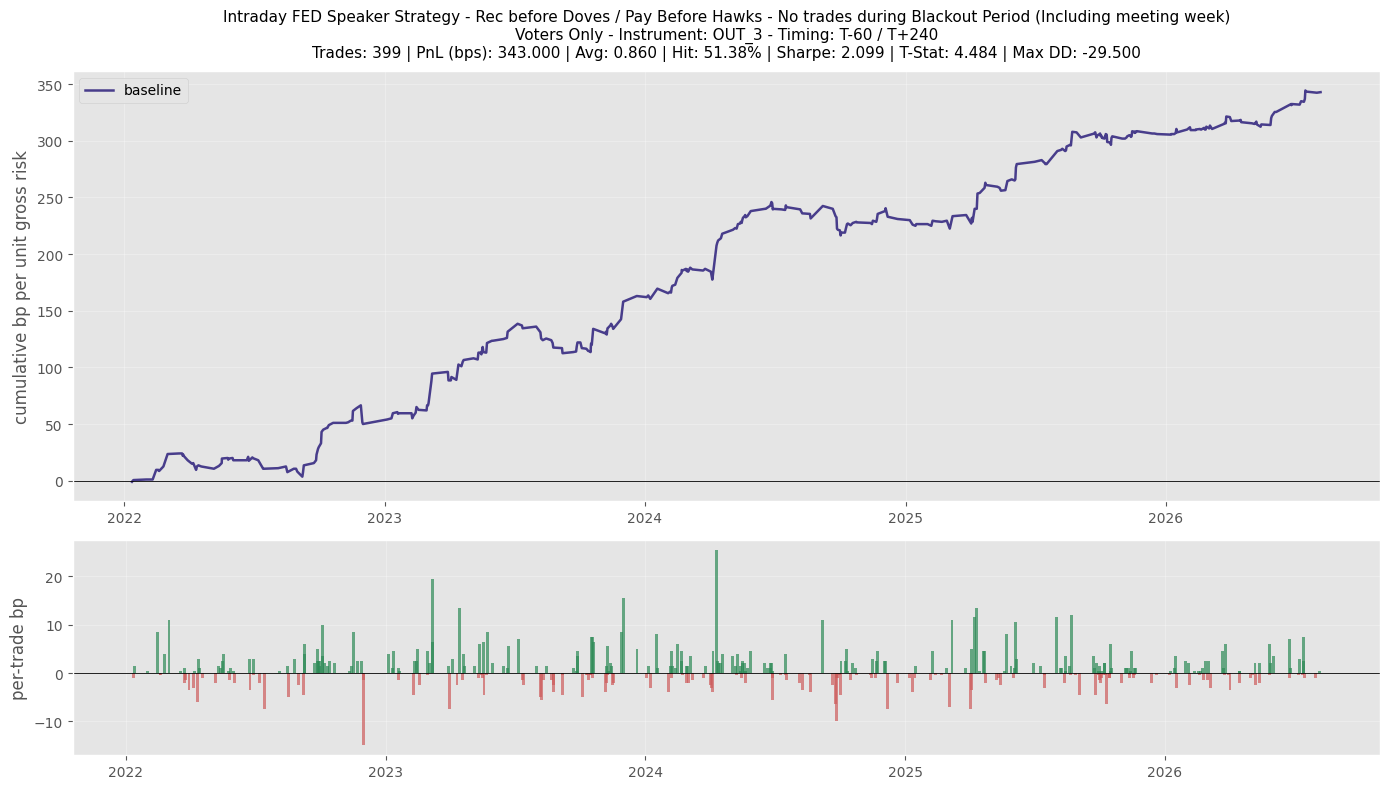

In [164]:
def perf(df, label):
    if df is None or df.empty:
        return {"book": label, "trades": 0}
    s = G.summarize(df)
    return {"book": label, "trades": s["trades"], "total_bp": s["total"],
            "avg_bp": s["avg"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
            "t_stat": s["t_stat"], "max_dd": s["max_dd"]}

rows = [perf(CLOSED, CONFIG.get("name", "config"))]
if not CLOSED.empty:
    rows.append(perf(CLOSED[CLOSED.timestamp_source == "forexfactory"], "  real timestamps"))
    rows.append(perf(CLOSED[CLOSED.abs_bucket == 2], "  conviction |2| only"))
display(pd.DataFrame(rows).set_index("book").round(4))

if not CLOSED.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})
    ax = axes[0]
    ax.plot(CLOSED.opened_at.values, CLOSED.pnl_bp.cumsum().values, lw=1.8,
            color="darkslateblue", label=CONFIG.get("name", "config"))
    if (CLOSED.era == "GE").any() and (CLOSED.era == "SR3").any():
        sp = pd.Timestamp("2022-01-01", tz=CLOSED.opened_at.dt.tz)
        ax.axvline(sp, color="crimson", ls=":", lw=1.6)
        ax.text(sp, ax.get_ylim()[1] * .95, "  GE -> SR3", color="crimson",
                fontsize=9, va="top")
    ax.axhline(0, color="k", lw=.6); ax.legend(); ax.grid(alpha=.3)
    ax.set_ylabel("cumulative bp per unit gross risk")
    # ax.set_title(f"{CONFIG.get('name')} — {RES.structure.name}, "
    #              f"T{CONFIG['timing']['entry_offset_min']:+d}/"
    #              f"T{CONFIG['timing']['exit_offset_min']:+d}")

    STRAT = [CONFIG["instrument"]]
    inst_cfgs = [{**copy.deepcopy(CONFIG),
                "name": i.get("structure") or f"OUT_{i['rank']}",
                "instrument": i} for i in STRAT]
    inst_tbl, inst_res = HC.compare(inst_cfgs, RAW, MDP)
    ssd = inst_tbl.iloc[0].to_dict()

    ax.set_title(
        "Intraday FED Speaker Strategy - Rec before Doves / Pay Before Hawks - No trades during Blackout Period (Including meeting week)\n"
        f"Voters Only - Instrument: {ssd["structure"]} - Timing: T{CONFIG['timing']['entry_offset_min']:+d} / T{CONFIG['timing']['exit_offset_min']:+d}\n"
        f"Trades: {ssd["trades"]} | PnL (bps): {ssd["total_bp"]:.3f} | Avg: {ssd["avg_bp"]:.3f} | Hit: {ssd["hit"]:.2%} | Sharpe: {ssd["sharpe"]:.3f} | T-Stat: {ssd["t_stat"]:.3f} | Max DD: {ssd["max_dd"]:.3f}",
        fontsize=11, 
        pad=10
    )

    ax = axes[1]
    _span = CLOSED.opened_at.max() - CLOSED.opened_at.min()
    _w = _span / min(len(CLOSED), 400) if _span and len(CLOSED) else pd.Timedelta(days=1)
    ax.bar(CLOSED.opened_at.values, CLOSED.pnl_bp.values, width=_w, alpha=.7,
           color=["seagreen" if x > 0 else "indianred" for x in CLOSED.pnl_bp])
    ax.axhline(0, color="k", lw=.6); ax.set_ylabel("per-trade bp"); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 5. The instrument knob

Outrights along the strip, calendar spreads, butterflies and packs — every one priced on the same
events, because a package is only kept where all its legs have a genuine mark.

Weights are in **rate space**, so a hawk always takes the structure long and the search is about
which package expresses the view, never about which sign to use.

,symbol-days,missing,usable
rank,,,
1,379,0,yes
2,379,0,yes
3,379,0,yes
4,379,0,yes
5,379,0,yes
6,379,0,yes
7,379,99,NOT WARMED
8,379,99,NOT WARMED


warm ranks: [1, 2, 3, 4, 5, 6]
to warm the rest:  python _prewarm_manual_ranks.py --events events_manual_raw.pkl --ranks 7,8


,structure,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd,first,last
name,,,,,,,,,,
OUT_1,OUT_1,402,89.7500,0.2233,0.4602,1.0497,2.2426,-39.250,2022-01-11,2026-08-05
OUT_2,OUT_2,402,257.0000,0.6393,0.5050,1.9717,4.2123,-29.500,2022-01-11,2026-08-05
OUT_3,OUT_3,399,343.0000,0.8596,0.5138,2.0989,4.4840,-29.500,2022-01-11,2026-08-05
OUT_4,OUT_4,402,344.5000,0.8570,0.5025,1.8405,3.9319,-37.000,2022-01-11,2026-08-05
OUT_5,OUT_5,402,333.0000,0.8284,0.5174,1.6426,3.5092,-46.500,2022-01-11,2026-08-05
OUT_6,OUT_6,403,303.5000,0.7531,0.5112,1.4810,3.1640,-48.000,2022-01-11,2026-08-05
SPR_1_2,SPR_1_2,401,82.6250,0.2060,0.5262,2.2460,4.7983,-4.625,2022-01-11,2026-08-05
SPR_2_3,SPR_2_3,398,46.2500,0.1162,0.4749,1.7687,3.7786,-7.500,2022-01-11,2026-08-05
SPR_3_4,SPR_3_4,398,-0.0000,-0.0000,0.3920,-0.0000,-0.0000,-10.000,2022-01-11,2026-08-05


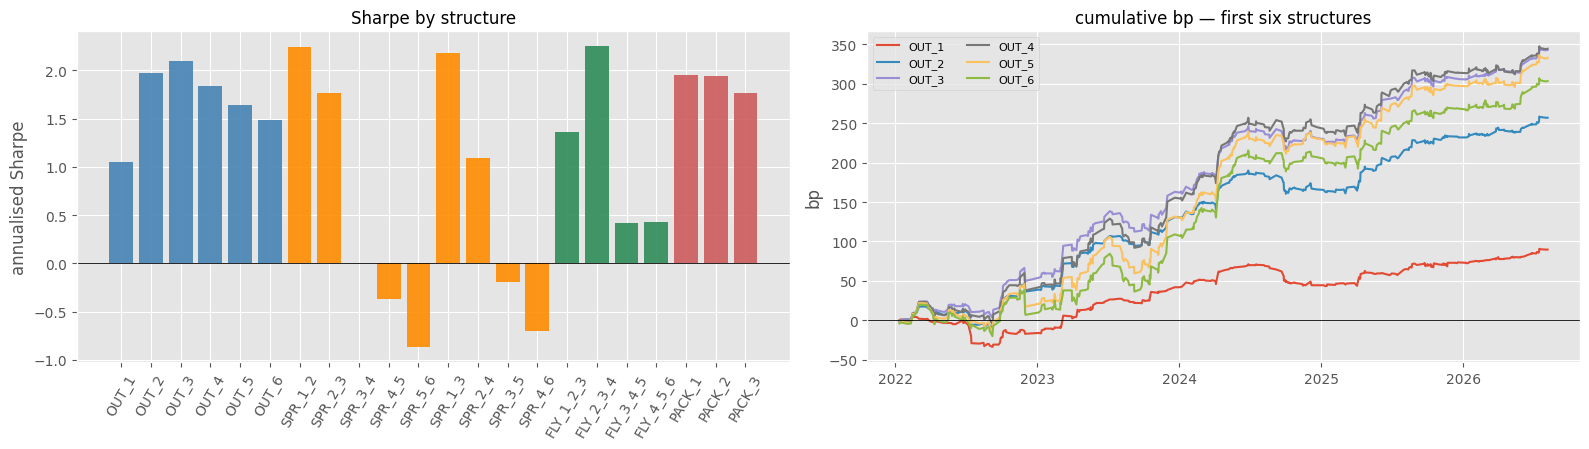

Every structure is scored on the same event set, so these differ by instrument
and not by which days each one happened to be able to price.


In [155]:
# Which ranks can this kernel actually price? It cannot fetch, so a rank whose
# bars were never warmed is not a thin result, it is no result — and the two must
# not be confused. Ask the cache, then build the instrument list from the answer.
_cfgF = G.CB_CONFIGS[CONFIG["bank"]]
_timed, _ = HC.retime(HC.apply_filters(RAW, CONFIG["filters"])[0], _cfgF,
                      CONFIG["timing"]["entry_offset_min"],
                      CONFIG["timing"]["exit_offset_min"],
                      CONFIG["timing"].get("retime_synthetic", False))
cov = {r: HC.check_coverage(_timed, _cfgF, [r]) for r in range(1, 9)}
cov_tbl = pd.DataFrame([{"rank": r, "symbol-days": c["wanted"],
                         "missing": len(c["missing"]),
                         "usable": "yes" if c["ok"] else "NOT WARMED"}
                        for r, c in cov.items()]).set_index("rank")
display(cov_tbl)
WARM = [r for r, c in cov.items() if c["ok"]]
print(f"warm ranks: {WARM}")
if len(WARM) < 8:
    print(f"to warm the rest:  python _prewarm_manual_ranks.py "
          f"--events events_manual_raw.pkl --ranks "
          f"{','.join(str(r) for r in range(1, 9) if r not in WARM)}")

_cat = HC.catalogue(max(WARM) if WARM else 3)
INSTRUMENTS = ([{"kind": "outright", "rank": n} for n in WARM] +
               [{"structure": s.name} for s in _cat.values()
                if s.kind != "outright" and set(s.ranks) <= set(WARM)])
inst_cfgs = [{**copy.deepcopy(CONFIG),
              "name": i.get("structure") or f"OUT_{i['rank']}",
              "instrument": i} for i in INSTRUMENTS]
inst_tbl, inst_res = HC.compare(inst_cfgs, RAW, MDP)
display(inst_tbl.round(4))

ok = inst_tbl[inst_tbl.trades > 0].copy()
if len(ok):
    ok["kind"] = [inst_res[n].structure.kind for n in ok.index]
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
    colors = {"outright": "steelblue", "spread": "darkorange",
              "fly": "seagreen", "pack": "indianred"}
    axes[0].bar(ok.index, ok.sharpe, color=[colors.get(k, "grey") for k in ok.kind], alpha=.9)
    axes[0].axhline(0, color="k", lw=.6); axes[0].set_ylabel("annualised Sharpe")
    axes[0].set_title("Sharpe by structure"); axes[0].tick_params(axis="x", rotation=60)
    for nm in ok.index[:6]:
        c = inst_res[nm].closed
        axes[1].plot(c.opened_at.values, c.pnl_bp.cumsum().values, lw=1.5, label=nm)
    axes[1].axhline(0, color="k", lw=.6); axes[1].legend(ncol=2, fontsize=8)
    axes[1].set_title("cumulative bp — first six structures"); axes[1].set_ylabel("bp")
    plt.tight_layout(); plt.show()
    print("Every structure is scored on the same event set, so these differ by instrument")
    print("and not by which days each one happened to be able to price.")

## 6. The timing knob

Entry and exit, in minutes around the speech. Both are clamped into the market's measured session,
so a wide exit cannot walk past the last bar of the day — it is pulled back to the close and the
trade is dropped if what remains is under 30 minutes.

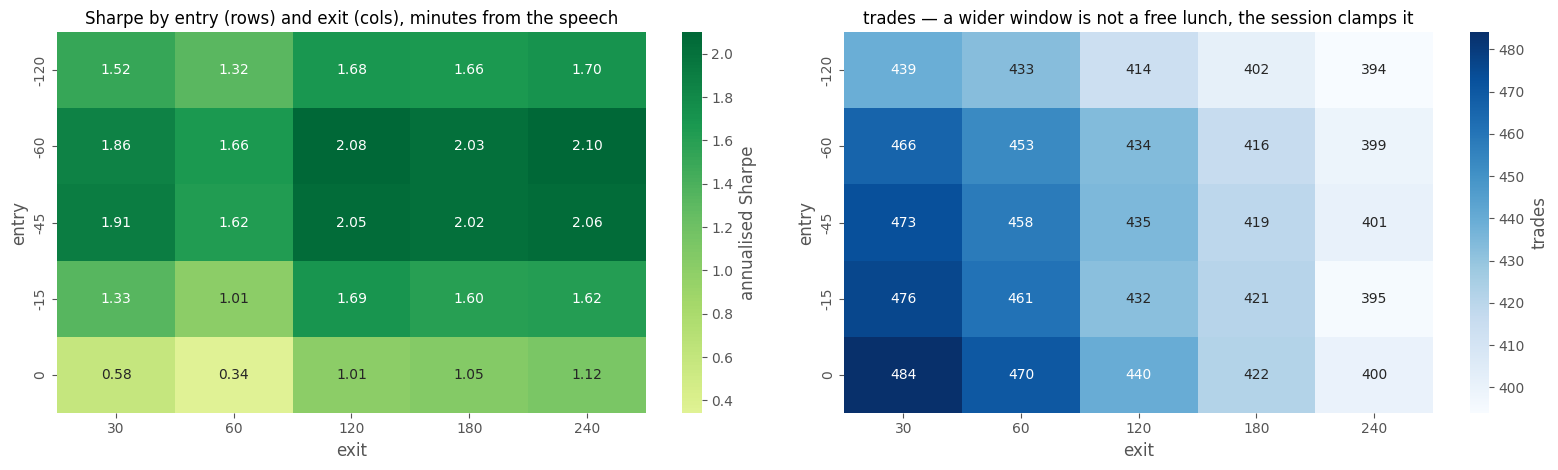

,structure,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd,first,last
name,,,,,,,,,,
-60|240,OUT_3,399,343.0,0.8596,0.5138,2.0989,4.4840,-29.5,2022-01-11,2026-08-05
-60|120,OUT_3,434,309.5,0.7131,0.5000,2.0850,4.4542,-25.0,2022-01-11,2026-08-05
-45|240,OUT_3,401,332.0,0.8279,0.5162,2.0554,4.3911,-29.5,2022-01-11,2026-08-05
-45|120,OUT_3,435,303.0,0.6966,0.5057,2.0514,4.3826,-26.5,2022-01-11,2026-08-05
-60|180,OUT_3,416,322.0,0.7740,0.4952,2.0256,4.3273,-27.5,2022-01-11,2026-08-05
-45|180,OUT_3,419,318.0,0.7589,0.5107,2.0237,4.3234,-28.0,2022-01-11,2026-08-05
-45|30,OUT_3,473,249.5,0.5275,0.4715,1.9129,4.0866,-22.0,2022-01-11,2026-08-05
-60|30,OUT_3,466,248.0,0.5322,0.4678,1.8630,3.9799,-21.5,2022-01-11,2026-08-05


In [156]:
ENTRY = [-120, -60, -45, -15, 0]
EXIT = [30, 60, 120, 180, 240]
tim_cfgs = [{**copy.deepcopy(CONFIG), "name": f"{e}|{x}",
             "timing": {**CONFIG["timing"], "entry_offset_min": e, "exit_offset_min": x}}
            for e in ENTRY for x in EXIT]
tim_tbl, tim_res = HC.compare(tim_cfgs, RAW, MDP)

grid_sr = pd.DataFrame(index=ENTRY, columns=EXIT, dtype=float)
grid_n = pd.DataFrame(index=ENTRY, columns=EXIT, dtype=float)
for e in ENTRY:
    for x in EXIT:
        r = tim_tbl.loc[f"{e}|{x}"] if f"{e}|{x}" in tim_tbl.index else None
        if r is not None:
            grid_sr.loc[e, x] = r.get("sharpe", np.nan)
            grid_n.loc[e, x] = r.get("trades", np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
sns.heatmap(grid_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            ax=axes[0], cbar_kws={"label": "annualised Sharpe"})
axes[0].set_title("Sharpe by entry (rows) and exit (cols), minutes from the speech")
axes[0].set_xlabel("exit"); axes[0].set_ylabel("entry")
sns.heatmap(grid_n.astype(float), annot=True, fmt=".0f", cmap="Blues", ax=axes[1],
            cbar_kws={"label": "trades"})
axes[1].set_title("trades — a wider window is not a free lunch, the session clamps it")
axes[1].set_xlabel("exit"); axes[1].set_ylabel("entry")
plt.tight_layout(); plt.show()
display(tim_tbl.sort_values("sharpe", ascending=False).head(8).round(4))

## 7. The filter knob

Each row re-runs the whole pipeline with one filter changed, so the overlap rule is resolved
**within** that book. That is why voters-only trades **672** events where a voters-only split of
the baseline has **626** — 46 voter speeches that a non-voter's position had been sitting in front
of. The two are different questions, and this is the one that asks "what if I only traded voters".

`voters` is the one cut here that is economically motivated rather than searched: the rotation is
published years ahead, so it is known at trade time and fitted to nothing.

Two rows below are identical by construction, not by accident: governors vote at every meeting, so
every non-voter in this book *is* a regional president in an off year. `non-voters` and
`Presidents, not voting` are the same trades.

,structure,trades,total_bp,avg_bp,hit,sharpe,t_stat,max_dd,first,last
name,,,,,,,,,,
all trades,OUT_3,399,343.0,0.8596,0.5138,2.0989,4.4840,-29.5,2022-01-11,2026-08-05
voters only,OUT_3,399,343.0,0.8596,0.5138,2.0989,4.4840,-29.5,2022-01-11,2026-08-05
non-voters,OUT_3,196,-75.0,-0.3827,0.4235,-0.5394,-1.1377,-79.5,2022-02-23,2026-08-07
Chair + Governors,OUT_3,242,169.0,0.6983,0.4876,1.2477,2.6639,-26.5,2022-01-13,2026-08-05
regional Presidents,OUT_3,235,167.0,0.7106,0.4979,1.6014,3.4149,-25.5,2022-01-11,2026-07-31
"Presidents, voting",OUT_3,235,167.0,0.7106,0.4979,1.6014,3.4149,-25.5,2022-01-11,2026-07-31
"Presidents, not voting",OUT_3,196,-75.0,-0.3827,0.4235,-0.5394,-1.1377,-79.5,2022-02-23,2026-08-07
conviction |2| only,OUT_3,228,196.0,0.8596,0.5000,1.5968,3.4052,-25.5,2022-01-11,2026-07-31
hawks only,OUT_3,268,224.0,0.8358,0.5448,1.5615,3.3360,-25.5,2022-01-11,2026-08-05


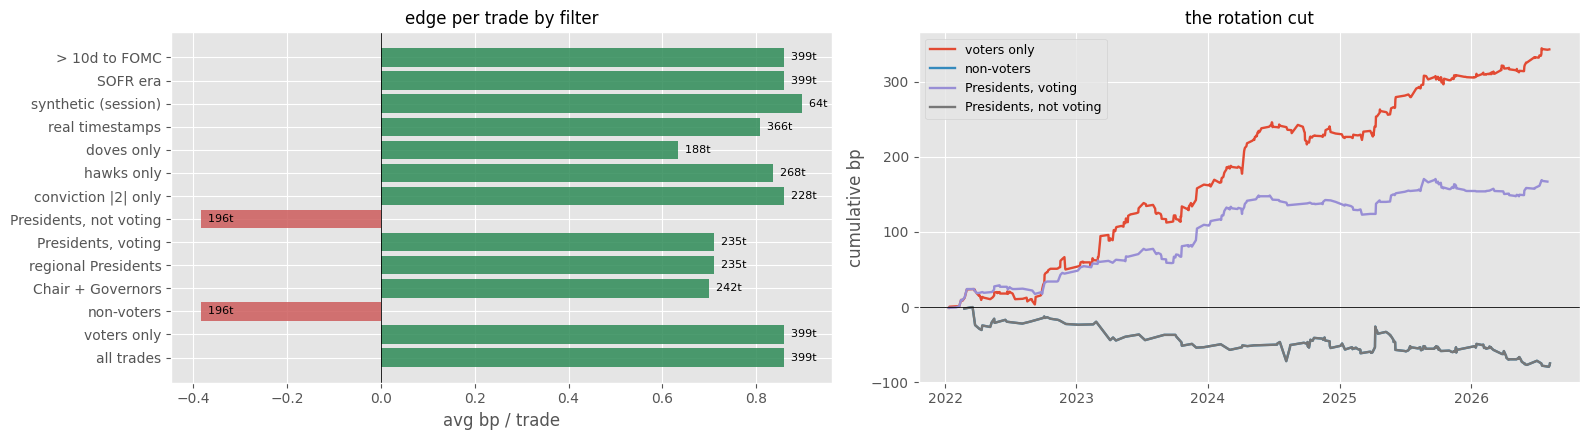

In [157]:
FILTER_CFGS = [
    {"name": "all trades", "filters": {}},
    {"name": "voters only", "filters": {"voters": "voters"}},
    {"name": "non-voters", "filters": {"voters": "nonvoters"}},
    {"name": "Chair + Governors", "filters": {"roles": ["Chair", "Governor"]}},
    {"name": "regional Presidents", "filters": {"roles": ["President", "President (NY)"]}},
    {"name": "Presidents, voting", "filters": {"roles": ["President", "President (NY)"],
                                               "voters": "voters"}},
    {"name": "Presidents, not voting", "filters": {"roles": ["President", "President (NY)"],
                                                   "voters": "nonvoters"}},
    {"name": "conviction |2| only", "filters": {"min_abs_bucket": 2}},
    {"name": "hawks only", "filters": {"direction": "hawk"}},
    {"name": "doves only", "filters": {"direction": "dove"}},
    {"name": "real timestamps", "filters": {"timestamp_source": "forexfactory"}},
    {"name": "synthetic (session)", "filters": {"timestamp_source": "synthetic"}},
    {"name": "Eurodollar era", "filters": {"era": "GE"}},
    {"name": "SOFR era", "filters": {"era": "SR3"}},
    {"name": "<= 10d to FOMC", "filters": {"days_to_fomc_max": 10}},
    {"name": "> 10d to FOMC", "filters": {"days_to_fomc_min": 11}},
]
flt_cfgs = [{**copy.deepcopy(CONFIG), "name": c["name"],
             "filters": {**CONFIG["filters"], **c["filters"]}} for c in FILTER_CFGS]
flt_tbl, flt_res = HC.compare(flt_cfgs, RAW, MDP)
display(flt_tbl.round(4))

ok = flt_tbl[flt_tbl.trades > 0]
fig, axes = plt.subplots(1, 2, figsize=(16, max(4.5, .32 * len(ok))))
axes[0].barh(ok.index, ok.avg_bp,
             color=["seagreen" if x > 0 else "indianred" for x in ok.avg_bp], alpha=.85)
axes[0].axvline(0, color="k", lw=.6); axes[0].set_xlabel("avg bp / trade")
axes[0].set_title("edge per trade by filter")
for i, (nm, r) in enumerate(ok.iterrows()):
    axes[0].text(r.avg_bp, i, f"  {int(r.trades)}t", va="center", fontsize=8)
for nm in ["voters only", "non-voters", "Presidents, voting", "Presidents, not voting"]:
    if nm in flt_res and not flt_res[nm].closed.empty:
        c = flt_res[nm].closed
        axes[1].plot(c.opened_at.values, c.pnl_bp.cumsum().values, lw=1.7, label=nm)
axes[1].axhline(0, color="k", lw=.6); axes[1].legend(fontsize=9)
axes[1].set_title("the rotation cut"); axes[1].set_ylabel("cumulative bp")
plt.tight_layout(); plt.show()

### 7.1 The rotation as a natural experiment

Governors always vote, so "voters beat non-voters" may only be saying *governors matter more*.
Restricting to regional presidents removes that: same job, differing only by whether the published
rotation gives them a vote that year — exogenous to what they say and to what the market does.

Because each side is now its own config, each resolves its own overlaps, and the two books are
independent draws rather than a split of one.

,trades,total_bp,avg_bp,hit
group,,,,
"President, VOTING",235,167.0,0.7106,0.4979
"President, NOT voting",196,-75.0,-0.3827,0.4235


gap +1.0933 bp/trade    two-sided permutation p = 0.0050


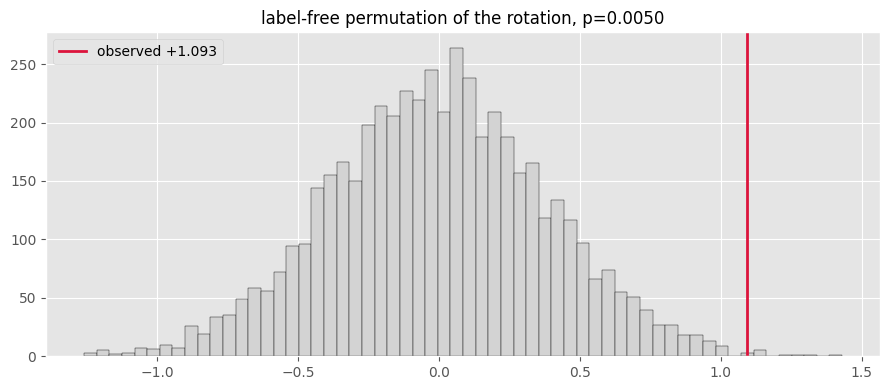

In [158]:
a = flt_res.get("Presidents, voting")
b = flt_res.get("Presidents, not voting")
if a is not None and b is not None and not a.closed.empty and not b.closed.empty:
    x, y = a.closed.pnl_bp, b.closed.pnl_bp
    obs = x.mean() - y.mean()
    rng = np.random.default_rng(11)
    pool = np.concatenate([x.to_numpy(), y.to_numpy()])
    n = len(x)
    perm = np.empty(5000)
    for i in range(5000):
        p = rng.permutation(pool)
        perm[i] = p[:n].mean() - p[n:].mean()
    pval = float((np.abs(perm) >= abs(obs)).mean())
    display(pd.DataFrame([
        {"group": "President, VOTING", "trades": len(x), "total_bp": x.sum(),
         "avg_bp": x.mean(), "hit": (x > 0).mean()},
        {"group": "President, NOT voting", "trades": len(y), "total_bp": y.sum(),
         "avg_bp": y.mean(), "hit": (y > 0).mean()},
    ]).set_index("group").round(4))
    print(f"gap {obs:+.4f} bp/trade    two-sided permutation p = {pval:.4f}")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(perm, bins=60, color="lightgrey", edgecolor="k", lw=.3)
    ax.axvline(obs, color="crimson", lw=2, label=f"observed {obs:+.3f}")
    ax.set_title(f"label-free permutation of the rotation, p={pval:.4f}"); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print("one side of the rotation cut is empty under this config")

## 8. Costs

`cost_bp` is charged per unit of **gross** risk, so a two-legged spread pays twice what an outright
does on the same notional of risk. That is the conservative reading; a listed calendar spread is
often quoted tighter than its legs, and the SR3 butterfly measurably trades one tick — so treat the
package rows as an upper bound on cost rather than a quote.

,baseline,voters only,real timestamps,conviction |2| only
cost_bp_rt,,,,
0.000,343.0,343.0,296.0,196.0
0.125,293.1,293.1,250.3,167.5
0.250,243.3,243.3,204.5,139.0
0.375,193.4,193.4,158.8,110.5
0.500,143.5,143.5,113.0,82.0
0.750,43.8,43.8,21.5,25.0
1.000,-56.0,-56.0,-70.0,-32.0


break-even round trip (bp): baseline 0.8596  voters only 0.8596  real timestamps 0.8087  conviction |2| only 0.8596


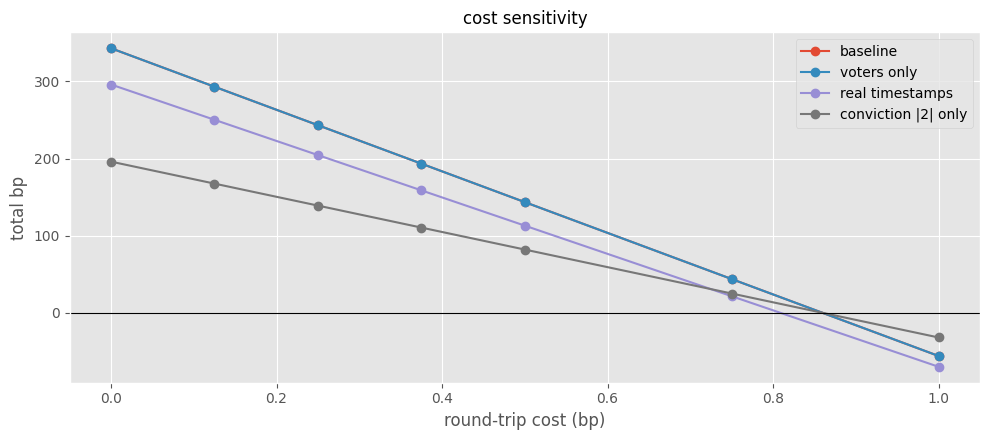

In [159]:
COSTS = [0.0, 0.125, 0.25, 0.375, 0.5, 0.75, 1]
books = {CONFIG.get("name", "config"): CLOSED}
for nm in ("voters only", "real timestamps", "conviction |2| only"):
    if nm in flt_res and not flt_res[nm].closed.empty:
        books[nm] = flt_res[nm].closed
rows = []
for c in COSTS:
    r = {"cost_bp_rt": c}
    for nm, df in books.items():
        r[nm] = df.pnl_bp_gross.sum() - c * len(df)
    rows.append(r)
cost_df = pd.DataFrame(rows).set_index("cost_bp_rt")
display(cost_df.round(1))
print("break-even round trip (bp): " + "  ".join(
    f"{nm} {df.pnl_bp_gross.mean():.4f}" for nm, df in books.items()))

fig, ax = plt.subplots(figsize=(10, 4.5))
cost_df.plot(marker="o", ax=ax)
ax.axhline(0, color="k", lw=.8); ax.set_ylabel("total bp"); ax.set_xlabel("round-trip cost (bp)")
ax.set_title("cost sensitivity")
plt.tight_layout(); plt.show()

## 9. What the search cost

This notebook ran a lot of configurations. Ranking them by Sharpe finds a good one whether or not
any signal exists, so the best number here has to be discounted by how many were tried.

The Deflated Sharpe compares the winner against `E[max Sharpe]` under the null that every
configuration has zero edge, using the spread of Sharpes the notebook actually observed as the
null's variance. It is the honest way to price the search — and it is *generous* here, because the
configurations are far from independent (they overlap heavily in events).

In [103]:
runs = {}
for src in (inst_res, tim_res, flt_res):
    for nm, r in src.items():
        if not r.closed.empty and len(r.closed) >= 20:
            runs[nm] = r.closed.pnl_bp.to_numpy(float)
runs[CONFIG.get("name", "config")] = CLOSED.pnl_bp.to_numpy(float)

sr_per_trade = {nm: (v.mean() / v.std(ddof=1)) if v.std(ddof=1) > 0 else 0.0
                for nm, v in runs.items()}
n_trials = len(runs)
var_sr = float(np.var(list(sr_per_trade.values()), ddof=1))
sr_star = GRID.expected_max_sharpe(var_sr, n_trials)

tbl = pd.DataFrame([
    {"config": nm, "trades": len(v), "sr_per_trade": sr_per_trade[nm],
     "total_bp": v.sum(), "dsr": GRID.deflated_sharpe(v, sr_star)}
    for nm, v in runs.items()
]).sort_values("sr_per_trade", ascending=False).set_index("config")
print(f"{n_trials} configurations scored   selection hurdle sr* = {sr_star:.4f} "
      f"per trade   (var of observed Sharpes {var_sr:.5f})")
display(tbl.head(15).round(4))

alive = tbl[(tbl.dsr > 0.95) & (tbl.trades >= 50)]
print(f"\nconfigs with DSR > 0.95 and >= 50 trades: {len(alive)} of {len(tbl)}")
if len(alive):
    display(alive.round(4))

62 configurations scored   selection hurdle sr* = 0.1771 per trade   (var of observed Sharpes 0.00564)


,trades,sr_per_trade,total_bp,dsr
config,,,,
"Presidents, voting",237,0.2742,195.00,0.9610
regional Presidents,237,0.2742,195.00,0.9610
hawks only,277,0.2161,228.50,0.7578
> 10d to FOMC,416,0.2122,322.00,0.7798
synthetic (session),66,0.2108,50.50,0.6079
SPR_1_2,431,0.2043,71.75,0.7257
SPR_1_3,428,0.1967,108.25,0.6639
-60|240,413,0.1815,302.50,0.5356
-45|240,415,0.1791,295.50,0.5162



configs with DSR > 0.95 and >= 50 trades: 2 of 62


,trades,sr_per_trade,total_bp,dsr
config,,,,
"Presidents, voting",237,0.2742,195.0,0.961
regional Presidents,237,0.2742,195.0,0.961


## 10. Robustness of the active config

sign-flip permutation — the null is that the LABEL carried no direction:
  realized Sharpe 1.988   null -0.004 +- 0.472   p = 0.0000


,trades,total_bp,avg_bp,hit,sharpe,range
half,,,,,,
1st half,215,52.625,0.2448,0.5721,2.5216,2022-01-11 -> 2024-06-17
2nd half,216,19.125,0.0885,0.4398,1.2796,2024-06-18 -> 2026-08-05


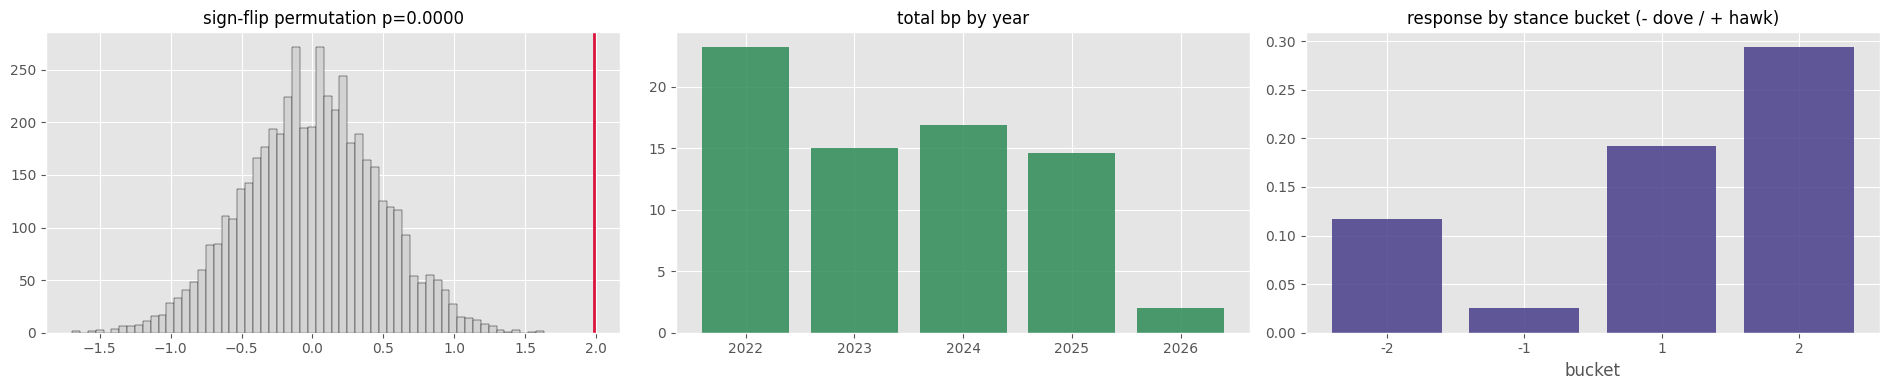

In [91]:
if not CLOSED.empty:
    r = G.sign_flip_permutation(CLOSED, n_perm=5000)
    print("sign-flip permutation — the null is that the LABEL carried no direction:")
    print(f"  realized Sharpe {r['realized_sharpe']:.3f}   null {r['perm_mean']:.3f}"
          f" +- {r['perm_std']:.3f}   p = {r['p_value']:.4f}")

    mid = len(CLOSED) // 2
    halves = []
    for name, sub in [("1st half", CLOSED.iloc[:mid]), ("2nd half", CLOSED.iloc[mid:])]:
        s = G.summarize(sub)
        halves.append({"half": name, "trades": s["trades"], "total_bp": s["total"],
                       "avg_bp": s["avg"], "hit": s["hit_rate"], "sharpe": s["sharpe"],
                       "range": f"{s['first'].date()} -> {s['last'].date()}"})
    display(pd.DataFrame(halves).set_index("half").round(4))

    fig, axes = plt.subplots(1, 3, figsize=(19, 4))
    axes[0].hist(r["perm"], bins=60, color="lightgrey", edgecolor="k", lw=.3)
    axes[0].axvline(r["realized_sharpe"], color="crimson", lw=2)
    axes[0].set_title(f"sign-flip permutation p={r['p_value']:.4f}")

    y = CLOSED.groupby("year").pnl_bp.sum()
    axes[1].bar(y.index.astype(str), y.values, alpha=.85,
                color=["seagreen" if v > 0 else "indianred" for v in y.values])
    axes[1].axhline(0, color="k", lw=.6); axes[1].set_title("total bp by year")

    b = CLOSED.groupby("bucket").pnl_bp.mean()
    axes[2].bar(b.index.astype(str), b.values, color="darkslateblue", alpha=.85)
    axes[2].axhline(0, color="k", lw=.6)
    axes[2].set_title("response by stance bucket (- dove / + hawk)")
    axes[2].set_xlabel("bucket")
    plt.tight_layout(); plt.show()

## 11. Trade log

In [92]:
if not CLOSED.empty:
    log = CLOSED[["opened_at", "closed_at", "speaker", "role", "is_voter", "era",
                  "symbol", "structure", "direction", "bucket", "days_to_fomc",
                  "timestamp_source", "d_rate_bp", "pnl_bp"]].copy()
    log["cum_bp"] = log.pnl_bp.cumsum()
    display(log.style.format({"pnl_bp": "{:+.3f}", "cum_bp": "{:+.2f}",
                              "d_rate_bp": "{:+.3f}"})
            .bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))
    out = CACHE / f"usd_fomc_config_{CONFIG.get('name','config').replace(' ', '_')}.csv"
    log.to_csv(out, index=False)
    summary = {"config": json.dumps(CONFIG, default=str), **{
        k: (round(float(v), 4) if isinstance(v, (int, float, np.floating)) else str(v))
        for k, v in G.summarize(CLOSED).items()}}
    pd.Series(summary).to_frame("value").to_csv(
        CACHE / f"usd_fomc_config_{CONFIG.get('name','config').replace(' ', '_')}_summary.csv")
    print(f"wrote {out}")

,opened_at,closed_at,speaker,role,is_voter,era,symbol,structure,direction,bucket,days_to_fomc,timestamp_source,d_rate_bp,pnl_bp,cum_bp
0,2022-01-11 08:12:00-05:00,2022-01-11 12:12:00-05:00,Mester,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,15,forexfactory,-0.500,-0.250,-0.25
1,2022-01-13 09:00:00-05:00,2022-01-13 13:00:00-05:00,Brainard,Governor,True,SR3,SR3U22,SPR_1_2,dove (long fut),-2,13,forexfactory,-1.000,+0.500,+0.25
2,2022-01-31 11:40:00-05:00,2022-01-31 15:40:00-05:00,George,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),1,44,forexfactory,+0.500,+0.250,+0.50
3,2022-02-09 09:30:00-05:00,2022-02-09 13:30:00-05:00,Bowman,Governor,True,SR3,SR3U22,SPR_1_2,hawk (short fut),1,35,forexfactory,+0.000,+0.000,+0.50
4,2022-02-14 07:30:00-05:00,2022-02-14 11:30:00-05:00,Bullard,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,30,forexfactory,+1.750,+0.875,+1.37
5,2022-02-17 10:00:00-05:00,2022-02-17 14:00:00-05:00,Bullard,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,27,forexfactory,+0.750,+0.375,+1.75
6,2022-02-17 16:00:00-05:00,2022-02-17 16:45:00-05:00,Mester,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,27,forexfactory,-0.500,-0.250,+1.50
7,2022-02-18 09:45:00-05:00,2022-02-18 13:45:00-05:00,Waller,Governor,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,26,forexfactory,+0.500,+0.250,+1.75
8,2022-02-24 11:00:00-05:00,2022-02-24 15:00:00-05:00,Mester,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,20,forexfactory,+2.250,+1.125,+2.88
9,2022-03-02 08:30:00-05:00,2022-03-02 12:30:00-05:00,Bullard,President,True,SR3,SR3U22,SPR_1_2,hawk (short fut),2,14,forexfactory,+9.250,+4.625,+7.50


wrote C:\Users\chris\clee\ARBS-gcb\notebooks\backtests\intraday_fed_hawk_dove\_global_cache\usd_fomc_config_baseline.csv


## 12. Reading this notebook

**The config is the claim.** A number here is only meaningful alongside the dict that produced it,
which is why the trade log is written out with its config attached.

**A knob that looks good is a hypothesis, not a result.** §9 exists because this notebook makes it
cheap to try hundreds of configurations, and the cheapest way to manufacture a Sharpe is to try
enough of them. Read the DSR column before the Sharpe column.

**The economically motivated cuts are worth more than the fitted ones.** The voter rotation is
published years ahead and known at trade time; entry and exit minutes are not — the timing surface
in §6 is a search, and its best cell should be read as the top of a distribution rather than as a
discovery.

**And the labels are still not point-in-time.** Every config inherits that ceiling. Changing the
instrument or the window does not make a hindsight label tradeable; it only changes how the
hindsight is expressed.